In [7]:
import h5py
from pathlib import Path

h5_path = Path('/home/mohamed-elarabie/BloodSensor/data/first_stage.h5')

if not h5_path.exists():
    raise FileNotFoundError(f'File not found: {h5_path}')

with h5py.File(h5_path, 'r') as f:
    print(f'Reading: {h5_path}')
    print('\nTop-level keys:')
    for key in f.keys():
        obj = f[key]
        if isinstance(obj, h5py.Dataset):
            print(f' - {key}: dataset, shape={obj.shape}, dtype={obj.dtype}')
        else:
            print(f' - {key}: group, items={len(obj.keys())}')

    if 'wavelength_nm' in f:
        wavelength_nm = f['wavelength_nm'][:]
        print(f"\nwavelength_nm sample (first 10): {wavelength_nm[:10]}")

    if 'transmittance' in f:
        transmittance = f['transmittance'][:]
        print(f'transmittance shape: {transmittance.shape}')

    if 'curves' in f:
        print('\nCurve datasets:')
        for curve_name in f['curves'].keys():
            curve = f['curves'][curve_name][:]
            print(f' - {curve_name}: shape={curve.shape}, min={curve.min():.6f}, max={curve.max():.6f}')


Reading: /home/mohamed-elarabie/BloodSensor/data/first_stage.h5

Top-level keys:
 - curves: group, items=6
 - ndtype: dataset, shape=(6,), dtype=object
 - ngtype: dataset, shape=(6,), dtype=object
 - transmittance: dataset, shape=(6, 901), dtype=float64
 - wavelength_nm: dataset, shape=(901,), dtype=float64

wavelength_nm sample (first 10): [450.  450.5 451.  451.5 452.  452.5 453.  453.5 454.  454.5]
transmittance shape: (6, 901)

Curve datasets:
 - Thyroid_na: shape=(901,), min=0.000826, max=0.977705
 - Thyroid_nc: shape=(901,), min=0.000712, max=0.969137
 - healthy_na: shape=(901,), min=0.000714, max=0.982105
 - healthy_nc: shape=(901,), min=0.000643, max=0.882234
 - water_na: shape=(901,), min=0.000876, max=0.930535
 - water_nc: shape=(901,), min=0.000748, max=0.906777


In [8]:
import h5py
import pandas as pd
from pathlib import Path

h5_path = Path('/home/mohamed-elarabie/BloodSensor/data/first_stage.h5')

if not h5_path.exists():
    raise FileNotFoundError(f'File not found: {h5_path}')

with h5py.File(h5_path, 'r') as f:
    wavelength_nm = f['wavelength_nm'][:]
    transmittance = f['transmittance'][:]

    ndtype = [x.decode() if isinstance(x, bytes) else str(x) for x in f['ndtype'][:]]
    ngtype = [x.decode() if isinstance(x, bytes) else str(x) for x in f['ngtype'][:]]

# Wide format: wavelength vs T columns
wide_data = {'wavelength_nm': wavelength_nm}
for i, (nd, ng) in enumerate(zip(ndtype, ngtype)):
    wide_data[f'T_{nd}_{ng}'] = transmittance[i]

df_wavelength_vs_T = pd.DataFrame(wide_data)

# Long format (optional): one row per wavelength-condition pair
df_long = df_wavelength_vs_T.melt(
    id_vars='wavelength_nm',
    var_name='condition',
    value_name='T',
)

print('DataFrame: wavelength vs T (wide)')
print(df_wavelength_vs_T.head())

print('\nShape (wide):', df_wavelength_vs_T.shape)
print('Shape (long):', df_long.shape)

df_wavelength_vs_T

DataFrame: wavelength vs T (wide)
   wavelength_nm  T_water_na  T_water_nc  T_healthy_na  T_healthy_nc  \
0          450.0    0.365060    0.370606      0.484460      0.494788   
1          450.5    0.348874    0.354467      0.483890      0.494994   
2          451.0    0.333591    0.339227      0.484628      0.496432   
3          451.5    0.319219    0.324882      0.486714      0.499142   
4          452.0    0.305749    0.311415      0.490192      0.503170   

   T_Thyroid_na  T_Thyroid_nc  
0      0.383373      0.389861  
1      0.368743      0.375450  
2      0.355073      0.361960  
3      0.342347      0.349369  
4      0.330540      0.337651  

Shape (wide): (901, 7)
Shape (long): (5406, 3)


,wavelength_nm,T_water_na,T_water_nc,T_healthy_na,T_healthy_nc,T_Thyroid_na,T_Thyroid_nc
0,450.0,0.365060,0.370606,0.484460,0.494788,0.383373,0.389861
1,450.5,0.348874,0.354467,0.483890,0.494994,0.368743,0.375450
2,451.0,0.333591,0.339227,0.484628,0.496432,0.355073,0.361960
3,451.5,0.319219,0.324882,0.486714,0.499142,0.342347,0.349369
4,452.0,0.305749,0.311415,0.490192,0.503170,0.330540,0.337651
...,...,...,...,...,...,...,...
896,898.0,0.408713,0.177925,0.307614,0.489711,0.405543,0.228991
897,898.5,0.410719,0.178059,0.310366,0.490075,0.408209,0.229105
898,899.0,0.412828,0.178166,0.313114,0.490575,0.410969,0.229203
899,899.5,0.415040,0.178251,0.315854,0.491210,0.413821,0.229288


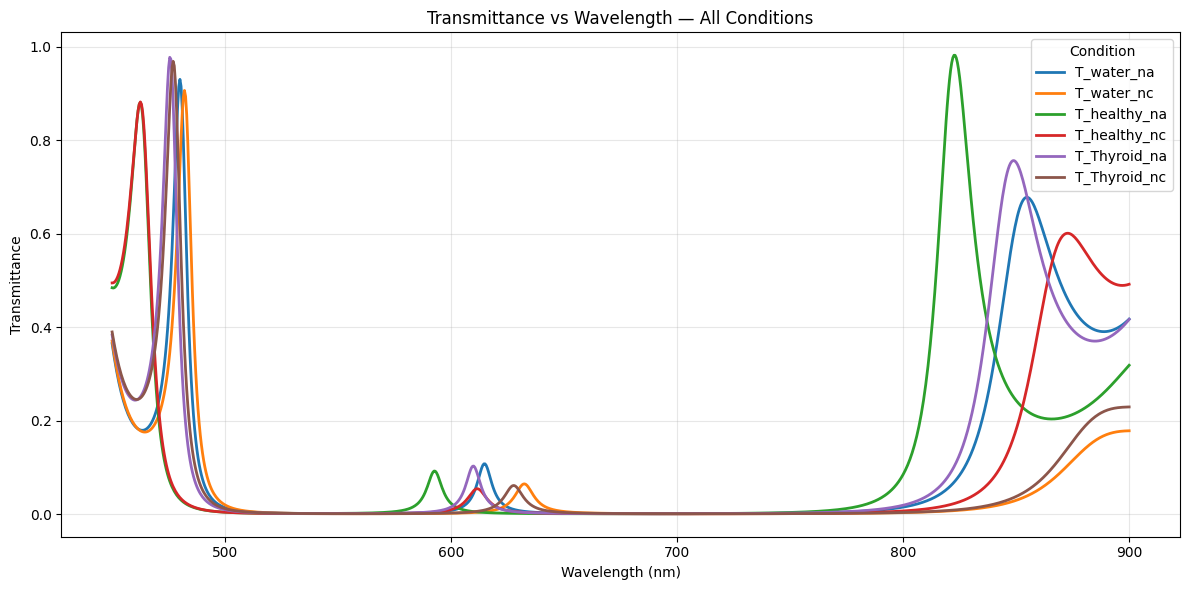

In [9]:
import matplotlib.pyplot as plt

x = 'wavelength_nm'

y_cols = [
    'T_water_na',
    'T_water_nc',
    'T_healthy_na',
    'T_healthy_nc',
    'T_Thyroid_na',
    'T_Thyroid_nc'
]

missing = [
    col for col in y_cols
    if col not in df_wavelength_vs_T.columns
]

if missing:
    raise KeyError(f'Missing columns in DataFrame: {missing}')

fig, ax = plt.subplots(figsize=(12, 6))

for col in y_cols:
    ax.plot(
        df_wavelength_vs_T[x],
        df_wavelength_vs_T[col],
        linewidth=2,
        label=col
    )

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Transmittance')

ax.set_title(
    'Transmittance vs Wavelength — All Conditions'
)

ax.grid(True, alpha=0.3)

ax.legend(
    title='Condition',
    loc='best'
)

plt.tight_layout()
plt.show()